## Many to Many

In [1]:
### autoreloader
%load_ext autoreload
%autoreload 2

In [2]:
### importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
### setting up the system path
import sys
sys.path.append('../')

In [4]:
### importing the src functions
from src.graphs.graphs_metrices import metrices, plot_predictions, plot_graphs_post_scaling
from src.future_pred.future_pred import gen_future_dates, gen_future_prices, gen_future_price_graphs

In [5]:
### loading up the data
df = pd.read_csv('../stocks/apple-18-2.csv')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19 00:00:00+00:00,129.87,130.7100,128.80,130.24,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22 00:00:00+00:00,126.00,129.7200,125.60,128.01,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23 00:00:00+00:00,125.86,126.7100,118.39,123.76,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24 00:00:00+00:00,125.35,125.5600,122.23,124.94,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25 00:00:00+00:00,120.99,126.4585,120.54,124.68,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [6]:
### making the df_copy
df_copy = df.copy()
df_copy.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19 00:00:00+00:00,129.87,130.7100,128.80,130.24,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22 00:00:00+00:00,126.00,129.7200,125.60,128.01,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23 00:00:00+00:00,125.86,126.7100,118.39,123.76,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24 00:00:00+00:00,125.35,125.5600,122.23,124.94,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25 00:00:00+00:00,120.99,126.4585,120.54,124.68,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [7]:
### changing the dtype of the date
df['date'] = df['date'].astype(dtype = 'date64[pyarrow]')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19,129.87,130.7100,128.80,130.24,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22,126.00,129.7200,125.60,128.01,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23,125.86,126.7100,118.39,123.76,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24,125.35,125.5600,122.23,124.94,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25,120.99,126.4585,120.54,124.68,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [8]:
### features to target : ['close', 'high', 'low', 'open']
features_to_target = ['close', 'high', 'low', 'open']
features_to_target

['close', 'high', 'low', 'open']

In [9]:
### scaling the features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
df[features_to_target] = scaler.fit_transform(df[features_to_target])
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19,0.079550,0.061271,0.075349,0.067057,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22,0.056763,0.055386,0.056197,0.053718,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23,0.055938,0.037493,0.013047,0.028295,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24,0.052935,0.030656,0.036028,0.035353,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25,0.027263,0.035998,0.025914,0.033798,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


feature : close


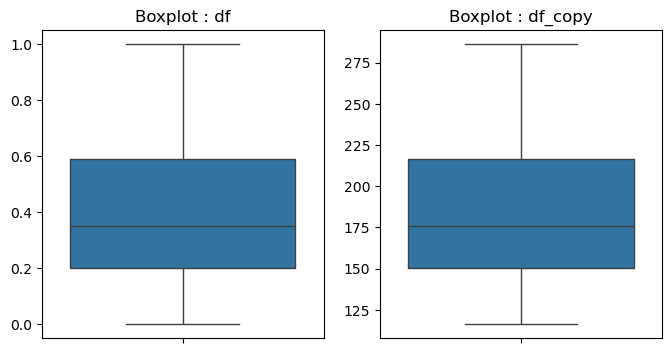

feature : high


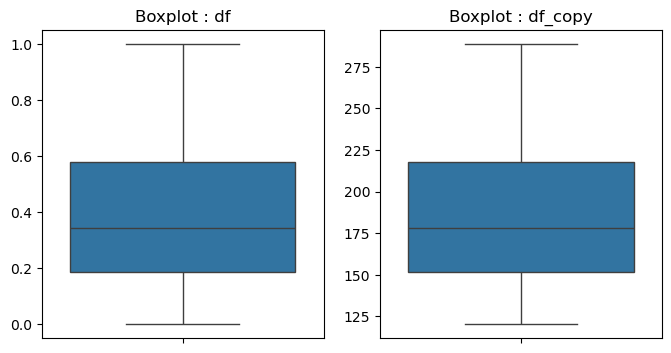

feature : low


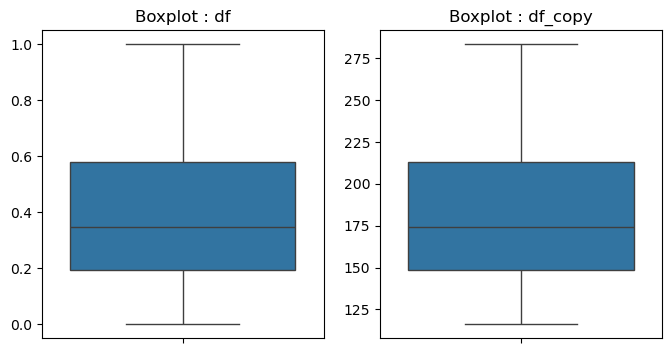

feature : open


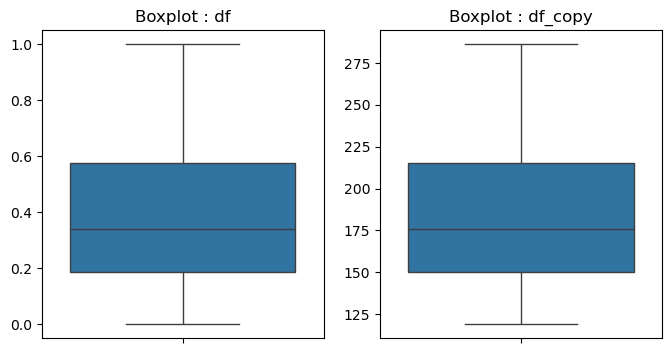

In [10]:
### plotting the graphs pre and post scaling
plot_graphs_post_scaling(df, df_copy, cols = features_to_target)

In [11]:
### making the sequences and the time period of 60 days
days = 60
X, y = [], []

for i in range(len(df) - days) : 

    X.append(df[features_to_target][i : i + days])
    y.append(df[features_to_target].iloc[i + days])

X = np.array(X)
y = np.array(y)

In [12]:
### checking the shape of the X and y
print(f"{X.shape} :: {y.shape}")

(1195, 60, 4) :: (1195, 4)


In [13]:
### verification of y
y

array([[0.05835247, 0.0388005 , 0.0536238 , 0.04659927],
       [0.04999117, 0.03915718, 0.05128972, 0.04504397],
       [0.04904905, 0.02682192, 0.03979891, 0.02470539],
       ...,
       [0.82093859, 0.84311921, 0.83332336, 0.855297  ],
       [0.86863334, 0.86725472, 0.83386199, 0.83160854],
       [0.87140081, 0.87040541, 0.87521695, 0.86480828]])

In [14]:
### checking the df['close'] from 61 to 64 index
df['close'].iloc[60 : 64]

60    0.058352
61    0.049991
62    0.049049
63    0.064476
Name: close, dtype: float64

In [15]:
### making the train and the test sequences (80-20)
test_size = int(len(df) * 0.80)
X_train, X_test = X[:test_size], X[test_size:]
y_train, y_test = y[:test_size], y[test_size:]

In [16]:
### checking the shape
print(f"{X_train.shape} :: {y_train.shape} \n{X_test.shape} :: {y_test.shape}")

(1004, 60, 4) :: (1004, 4) 
(191, 60, 4) :: (191, 4)


In [17]:
### libraries to build the model
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional

In [18]:
# ### building the sequential model
model = Sequential([
    LSTM(50, return_sequences = True, input_shape = (days, 4)),
    Dropout(0.33),
    Bidirectional(LSTM(100)),
    Dropout(0.33),
    Dense(4, activation = 'linear')
])
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mse'])

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
### checking the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200)            │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,604 (517.98 KB)

 Trainable params: 132,604 (517.98 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
### training the model
model.fit(X_train, y_train, batch_size = 32, epochs = 30, verbose = 1)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0406 - mse: 0.0406
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0064 - mse: 0.0064
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0058 - mse: 0.0058
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0045 - mse: 0.0045
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0043 - mse: 0.0043
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0037 - mse: 0.0037
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0038 - mse: 0.0038
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0039 - mse: 0.0039
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0029 - mse: 0.0029
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0032 - mse: 0.0032
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0030 - mse: 0.0030
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0029 - mse: 0.0029
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━

In [22]:
### predicting the y
y_pred = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step


In [23]:
### checking the y_pred
y_pred.shape

(191, 4)

In [24]:
### inverse scaling the y_test and y_pred
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test)

In [25]:
### checking the both
y_pred

array([[205.4271 , 208.458  , 203.4059 , 205.38307],
       [207.61667, 210.64345, 205.6608 , 207.62915],
       [209.19466, 212.24338, 207.23485, 209.24203],
       [209.44504, 212.52762, 207.38638, 209.49838],
       [208.98976, 212.11214, 206.82452, 209.021  ],
       [207.52736, 210.68073, 205.2479 , 207.51288],
       [205.62814, 208.81403, 203.25244, 205.5835 ],
       [202.79593, 206.0174 , 200.27568, 202.71124],
       [200.875  , 204.11395, 198.34727, 200.75209],
       [199.80028, 202.9793 , 197.3626 , 199.68727],
       [199.2834 , 202.40259, 196.94836, 199.17488],
       [198.93459, 202.032  , 196.70357, 198.82372],
       [198.98703, 202.0316 , 196.86696, 198.87897],
       [199.39188, 202.33969, 197.38533, 199.26866],
       [200.04066, 202.89897, 198.15317, 199.96579],
       [200.43744, 203.26286, 198.58305, 200.38043],
       [200.99075, 203.78596, 199.16022, 200.95285],
       [201.27834, 204.07166, 199.42644, 201.27876],
       [201.40414, 204.22719, 199.50925, 201.4

In [26]:
### checking the y_test
y_test

array([[211.45  , 212.96  , 209.54  , 210.95  ],
       [211.26  , 212.57  , 209.77  , 212.36  ],
       [208.78  , 209.48  , 204.26  , 207.91  ],
       [206.86  , 208.47  , 205.03  , 207.67  ],
       [202.09  , 207.04  , 200.71  , 205.17  ],
       [201.36  , 202.75  , 199.7   , 200.71  ],
       [195.27  , 197.7   , 193.46  , 193.665 ],
       [200.21  , 200.74  , 197.43  , 198.3   ],
       [200.42  , 202.73  , 199.9   , 200.59  ],
       [199.95  , 203.81  , 198.51  , 203.575 ],
       [200.85  , 201.96  , 196.78  , 199.37  ],
       [201.7   , 202.13  , 200.12  , 200.28  ],
       [203.27  , 203.77  , 200.955 , 201.35  ],
       [202.82  , 206.24  , 202.1   , 202.91  ],
       [200.63  , 204.75  , 200.15  , 203.5   ],
       [203.92  , 205.7   , 202.05  , 203.    ],
       [201.45  , 206.    , 200.02  , 204.39  ],
       [202.67  , 204.35  , 200.57  , 200.6   ],
       [198.78  , 204.5   , 198.41  , 203.5   ],
       [199.2   , 199.68  , 197.3601, 199.08  ],
       [196.45  , 20

In [27]:
### printing the metrices
for i in range(0, 4) : 
    print(f"feature : {features_to_target[i]}")
    metrices(y_test[:, i], y_pred[:, i])

feature : close
MAE : 7.529336525482658
MSE : 82.32236847961947
RMSE : 9.073167499810607
feature : high
MAE : 6.336508178199647
MSE : 62.074087762465346
RMSE : 7.878711047021927
feature : low
MAE : 7.136861264341665
MSE : 71.47761970911657
RMSE : 8.454443784727447
feature : open
MAE : 6.909828881069003
MSE : 67.85034373924127
RMSE : 8.237132009336822


feature : close


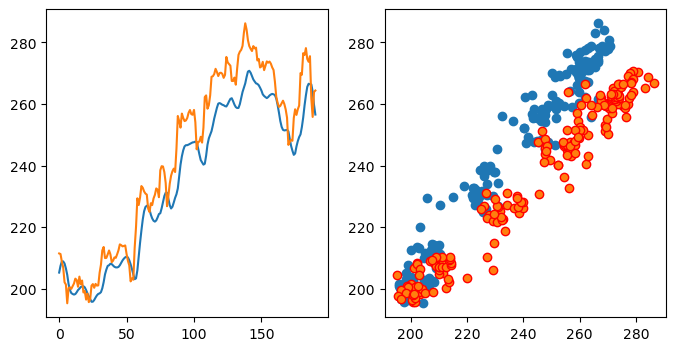

feature : high


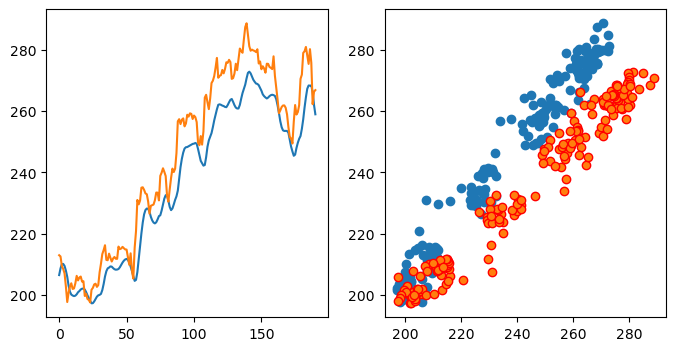

feature : low


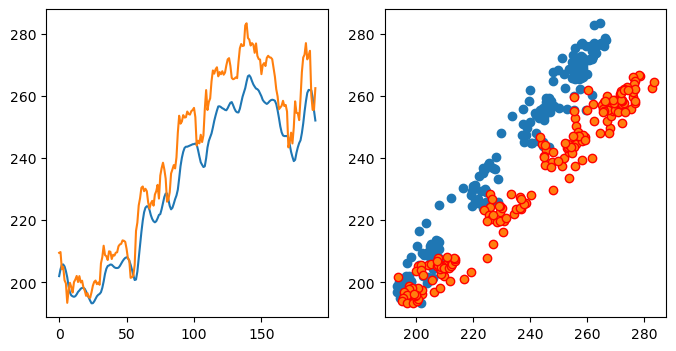

feature : open


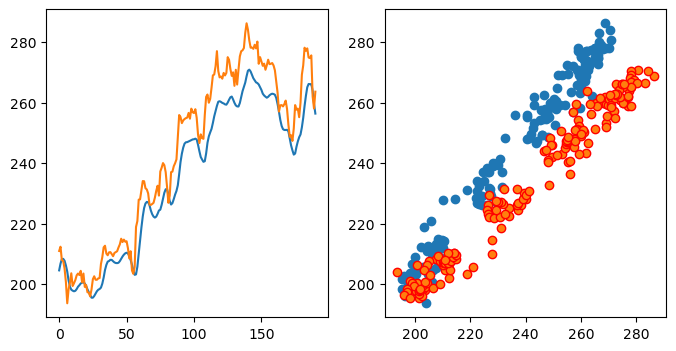

In [26]:
### plotting the graphs
for i in range (0, 4) : 
    print(f"feature : {features_to_target[i]}")
    plot_predictions(y_test[:, i], y_pred[:, i])

### working on the future predictions

##### 1. 30 days window

In [40]:
### getting the last sequence
window_size_30 = 30
last_sequence_30 = df[features_to_target][-window_size_30 : ]
last_sequence_30

,close,high,low,open
1225,0.859683,0.874745,0.873242,0.885147
1226,0.847730,0.851739,0.859417,0.862416
1227,0.840134,0.825642,0.834820,0.825447
1228,0.842077,0.831111,0.837932,0.837740
1229,0.847259,0.837591,0.841403,0.838248
1230,0.851970,0.840622,0.850919,0.835616
1231,0.845551,0.840682,0.840864,0.840223
1232,0.835247,0.836045,0.842899,0.847162
1233,0.819467,0.823323,0.830211,0.830711
1234,0.767473,0.798891,0.761326,0.799785


In [41]:
### checking out the shape
last_sequence_30 = np.array(last_sequence_30)
last_sequence_30.shape

(30, 4)

In [42]:
### reshaping it
last_sequence_30 = np.expand_dims(last_sequence_30, axis = 0)
last_sequence_30.shape

(1, 30, 4)

In [43]:
### checking the last sequence
last_sequence_30

array([[[0.85968321, 0.87474505, 0.87324197, 0.88514686],
        [0.84773008, 0.85173903, 0.85941708, 0.86241551],
        [0.84013425, 0.82564178, 0.83481956, 0.82544715],
        [0.84207737, 0.83111091, 0.83793165, 0.83774003],
        [0.84725902, 0.83759063, 0.84140284, 0.83824849],
        [0.85196962, 0.84062243, 0.85091867, 0.83561644],
        [0.84555143, 0.84068188, 0.8408642 , 0.84022253],
        [0.83524701, 0.83604501, 0.84289904, 0.84716157],
        [0.81946653, 0.82332334, 0.83021126, 0.83071125],
        [0.76747336, 0.7988906 , 0.76132623, 0.79978465],
        [0.77306718, 0.7796892 , 0.77185948, 0.77567745],
        [0.77718895, 0.77636016, 0.78963433, 0.77866842],
        [0.7753636 , 0.76690808, 0.76886708, 0.76742238],
        [0.81875994, 0.80941273, 0.79950925, 0.79230723],
        [0.83560031, 0.84145469, 0.8498414 , 0.83830831],
        [0.82482482, 0.82305583, 0.82769765, 0.82921577],
        [0.83565919, 0.82778187, 0.82709917, 0.83130945],
        [0.842

In [44]:
### predicting the future days and moving the window forward (future_days = window_size)
future_pred_30 = gen_future_prices(window_size = window_size_30, last_sequence = last_sequence_30, model = model, scaler = scaler)


In [47]:
### checking the future pred
future_pred_30

array([[43628.86026221, 43996.67306439, 42448.39220281, 42966.25214037],
       [43266.11506605, 43624.35663809, 42094.43849167, 42599.58159663],
       [42897.01768155, 43246.51987772, 41730.73478268, 42226.93285554],
       [42543.05896294, 42888.41498054, 41379.18237669, 41868.35761386],
       [42202.17079587, 42542.3205627 , 41043.56212286, 41524.9768877 ],
       [41878.13526811, 42211.67734571, 40726.19378513, 41198.94942426],
       [41569.28310365, 41894.85436009, 40424.42145011, 40886.73561103],
       [41276.29851654, 41593.25150726, 40140.53992017, 40591.56190892],
       [40994.06881177, 41300.7176542 , 39868.93949352, 40307.6133592 ],
       [40728.55077759, 41024.59469343, 39611.35416875, 40039.9453614 ],
       [40493.89114141, 40782.60234069, 39381.1101078 , 39811.9659978 ],
       [40276.90932734, 40561.72319964, 39165.04589524, 39598.0651307 ],
       [40073.75448235, 40356.25646697, 38961.34931949, 39397.1750464 ],
       [39893.01882223, 40180.4001788 , 38778.69702

In [73]:
### getting the last date index
last_date = df['date'].iloc[-1]
last_date

datetime.date(2026, 2, 18)

In [74]:
### generating the future 30 dates
future_dates_30 = gen_future_dates(last_date = last_date, window_size = window_size_30)
future_dates_30

DatetimeIndex(['2026-02-19', '2026-02-20', '2026-02-23', '2026-02-24',
               '2026-02-25', '2026-02-26', '2026-02-27', '2026-03-02',
               '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06',
               '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12',
               '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18',
               '2026-03-19', '2026-03-20', '2026-03-23', '2026-03-24',
               '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30',
               '2026-03-31', '2026-04-01'],
              dtype='datetime64[ns]', freq='B')

Feature : close


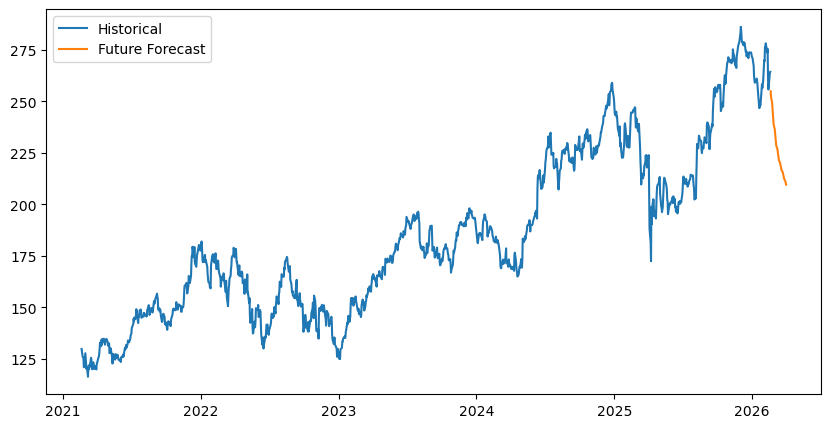

Feature : high


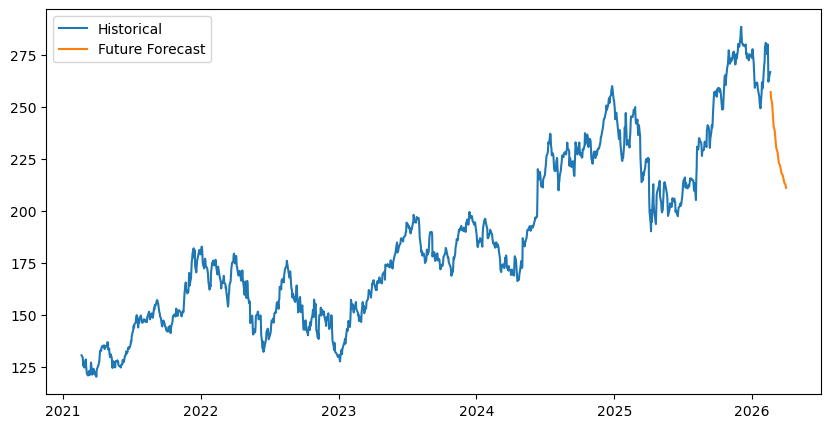

Feature : low


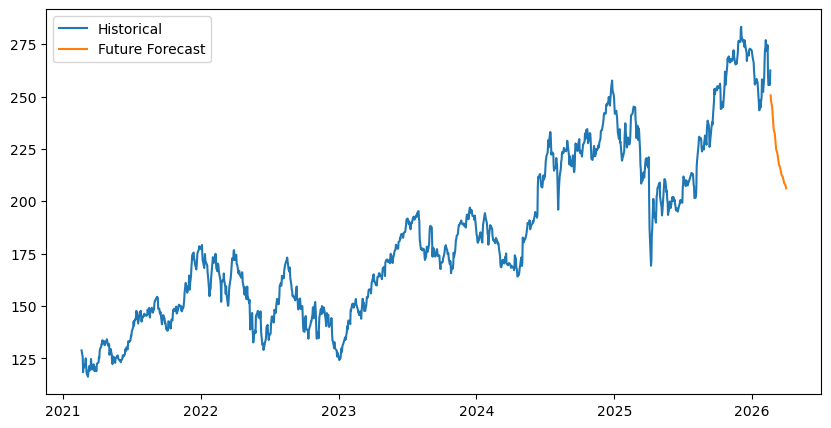

Feature : open


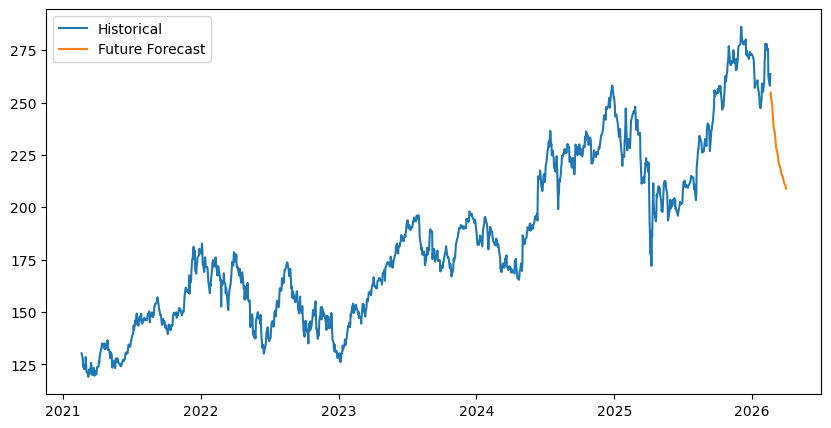

In [76]:
### plotting the next 30 days forecast
gen_future_price_graphs(df, df_copy, features_to_target, future_dates_30, future_pred_30)

##### 2. 60 days window

In [77]:
### getting the last sequence
window_size_60 = 60
last_sequence_60 = df[features_to_target][-window_size_60 : ]
last_sequence_60

,close,high,low,open
1195,0.882588,0.921589,0.895984,0.908058
1196,0.913443,0.909105,0.894488,0.878866
1197,0.939528,0.930923,0.925788,0.908476
1198,0.945710,0.951016,0.951822,0.934617
1199,0.949126,0.945963,0.960081,0.944727
1200,0.956780,0.942812,0.956230,0.946522
1201,0.981805,0.969088,0.957149,0.951008
1202,1.000000,0.992747,0.995991,0.980858
1203,0.987988,1.000000,1.000000,1.000000
1204,0.967674,0.976875,0.971812,0.987408


In [78]:
### changing the shape
last_sequence_60 = np.array(last_sequence_60)
last_sequence_60 = np.expand_dims(last_sequence_60, axis = 0)
last_sequence_60.shape

(1, 60, 4)

In [79]:
### predicting the next 60 days forecast
future_pred_60 = gen_future_prices(df, window_size_60, last_sequence_60, model = model)
future_pred_60

[array([0.8182317 , 0.8158051 , 0.80510974, 0.8132254 ], dtype=float32),
 array([0.80301106, 0.80067015, 0.78963745, 0.7975599 ], dtype=float32),
 array([0.78750044, 0.78476405, 0.77346015, 0.78115267], dtype=float32),
 array([0.7721004 , 0.7688645 , 0.75751257, 0.76487404], dtype=float32),
 array([0.7572012, 0.7535006, 0.7422466, 0.7492311], dtype=float32),
 array([0.7430807, 0.7390449, 0.728004 , 0.7344234], dtype=float32),
 array([0.72993445, 0.7256086 , 0.7148166 , 0.72059226], dtype=float32),
 array([0.71801126, 0.7130579 , 0.70250714, 0.7079638 ], dtype=float32),
 array([0.70669293, 0.7010654 , 0.6910324 , 0.6961067 ], dtype=float32),
 array([0.69580305, 0.68964326, 0.68023086, 0.68492216], dtype=float32),
 array([0.6855428 , 0.6790149 , 0.67011404, 0.67445475], dtype=float32),
 array([0.6759702 , 0.66913915, 0.66072404, 0.664637  ], dtype=float32),
 array([0.66709393, 0.6599413 , 0.6519309 , 0.65548563], dtype=float32),
 array([0.658646  , 0.6512203 , 0.64360905, 0.6468242 ], dt

In [80]:
### inverse scaling the forecast
future_pred_60 = scaler.inverse_transform(future_pred_60)
future_pred_60

array([[255.32028993, 257.63530115, 250.73578634, 254.9768882 ],
       [252.73536828, 255.08935004, 248.15052092, 252.35809132],
       [250.10119991, 252.41367596, 245.44745642, 249.61529111],
       [247.48580906, 249.7391048 , 242.78277523, 246.89399345],
       [244.95547891, 247.15463185, 240.23198904, 244.278963  ],
       [242.55739114, 244.72294283, 237.85218481, 241.80355961],
       [240.32476832, 242.46272716, 235.64870073, 239.49140816],
       [238.29985229, 240.35148536, 233.59191773, 237.3803125 ],
       [236.37766099, 238.33415184, 231.67460533, 235.39815241],
       [234.52823134, 236.41275195, 229.86977372, 233.52843727],
       [232.78573744, 234.6248851 , 228.17935501, 231.77860033],
       [231.16001851, 232.96361294, 226.61038049, 230.13737217],
       [229.65256258, 231.4163823 , 225.1411388 , 228.60753277],
       [228.21784806, 229.94936373, 223.75063565, 227.15959835],
       [226.88282146, 228.5637604 , 222.45050356, 225.80425043],
       [225.59500694, 227

In [81]:
### generating the futture dates (last date index remain the same though)
future_dates_60 = gen_future_dates(last_date, window_size_60)
future_dates_60

DatetimeIndex(['2026-02-19', '2026-02-20', '2026-02-23', '2026-02-24',
               '2026-02-25', '2026-02-26', '2026-02-27', '2026-03-02',
               '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06',
               '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12',
               '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18',
               '2026-03-19', '2026-03-20', '2026-03-23', '2026-03-24',
               '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30',
               '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-03',
               '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09',
               '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15',
               '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21',
               '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-27',
               '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01',
               '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07',
      

Feature : close


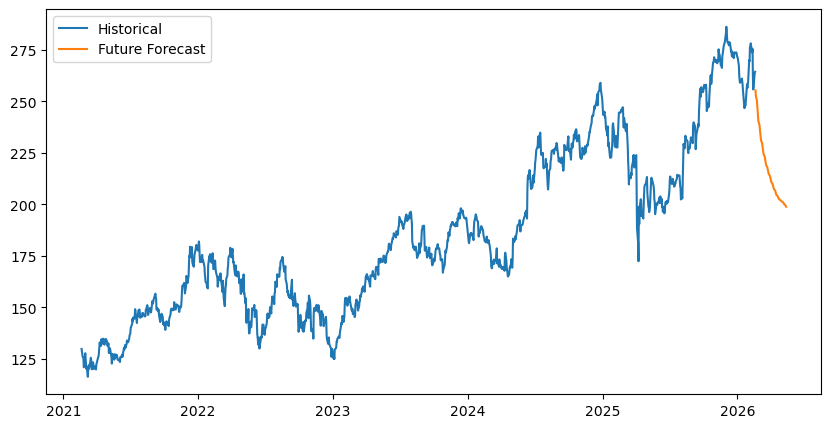

Feature : high


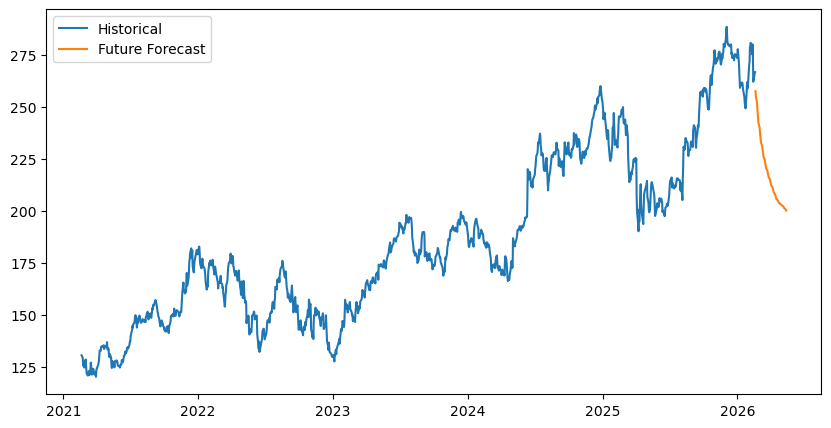

Feature : low


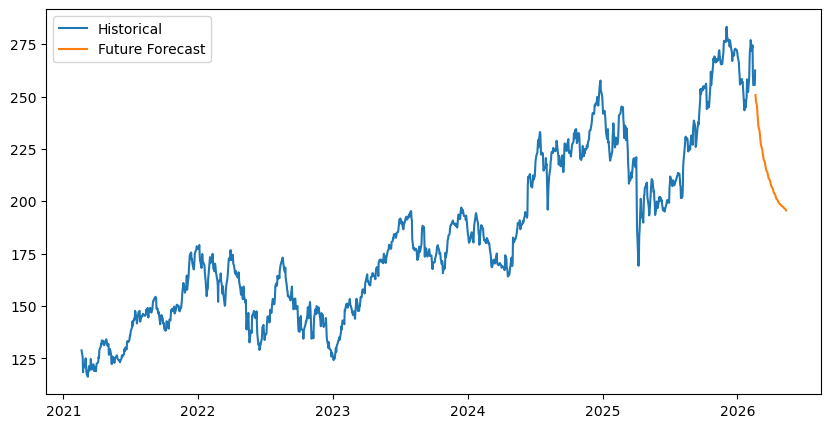

Feature : open


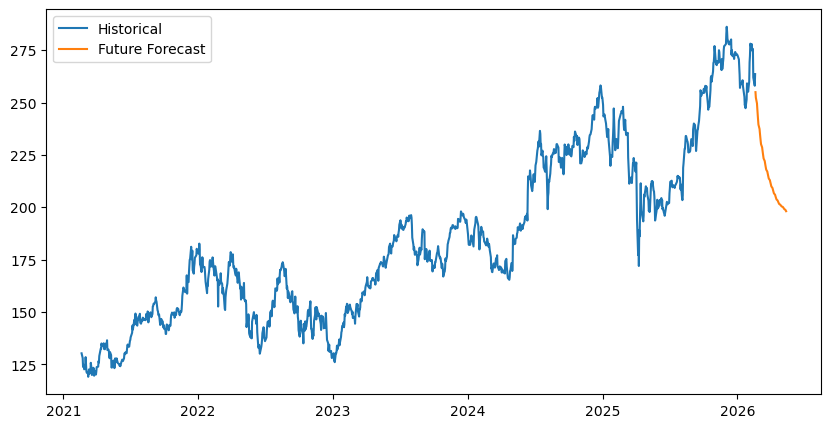

In [82]:
### plotting the graphs
gen_future_price_graphs(df, df_copy, features_to_target, future_dates_60, future_pred_60)

##### 3. 90 days window

In [83]:
### getting the last sequence
window_size_90 = 90
last_sequence_90 = df[features_to_target][-window_size_90 : ]
last_sequence_90

,close,high,low,open
1165,0.810693,0.817973,0.819498,0.830143
1166,0.759053,0.808343,0.764797,0.813005
1167,0.773126,0.768573,0.774134,0.779745
1168,0.773774,0.763549,0.768987,0.763115
1169,0.783018,0.781235,0.785565,0.780373
...,...,...,...,...
1250,0.937055,0.949827,0.947035,0.931178
1251,0.855974,0.923313,0.861631,0.936532
1252,0.820939,0.843119,0.833323,0.855297
1253,0.868633,0.867255,0.833862,0.831609


In [84]:
### modifying the shape
last_sequence_90 = np.array(last_sequence_90)
last_sequence_90 = np.expand_dims(last_sequence_90, axis = 0)
last_sequence_90.shape

(1, 90, 4)

In [85]:
### predicting the next 90 days forecast
future_pred_90 = gen_future_prices(df, window_size_90, last_sequence_90, model = model)
future_pred_90

[array([0.81508845, 0.8120656 , 0.8034544 , 0.8109622 ], dtype=float32),
 array([0.7990551 , 0.7957542 , 0.787385  , 0.79448706], dtype=float32),
 array([0.78169435, 0.7782606 , 0.76979303, 0.77677244], dtype=float32),
 array([0.7647874, 0.7610767, 0.7527102, 0.7591908], dtype=float32),
 array([0.74884737, 0.74473596, 0.73643804, 0.7424482 ], dtype=float32),
 array([0.73380345, 0.72927415, 0.7211704 , 0.7266634 ], dtype=float32),
 array([0.7198167 , 0.7151425 , 0.70706797, 0.71193403], dtype=float32),
 array([0.7072148 , 0.7021322 , 0.6940093 , 0.69848776], dtype=float32),
 array([0.69567186, 0.6897011 , 0.68182445, 0.68619984], dtype=float32),
 array([0.6845706 , 0.67796993, 0.6705977 , 0.6745757 ], dtype=float32),
 array([0.6741032 , 0.6672596 , 0.6601032 , 0.66378736], dtype=float32),
 array([0.6645692 , 0.6575422 , 0.6505642 , 0.65381527], dtype=float32),
 array([0.65586025, 0.6485504 , 0.6416676 , 0.6446693 ], dtype=float32),
 array([0.6478721, 0.640061 , 0.6334274, 0.6362481], dt

In [86]:
### inverse scaling the generated forecast
future_pred_90 = scaler.inverse_transform(future_pred_90)
future_pred_90

array([[254.78647162, 257.00625806, 250.45919555, 254.598551  ],
       [252.06352755, 254.26240372, 247.77415746, 251.84440167],
       [249.11515191, 251.31968361, 244.83471798, 248.88304871],
       [246.24384005, 248.42906125, 241.98035119, 245.94392567],
       [243.53674806, 245.68027387, 239.26143143, 243.14506739],
       [240.98184009, 243.07933739, 236.71036638, 240.50632236],
       [238.60646757, 240.70215247, 234.35398652, 238.0440118 ],
       [236.46628485, 238.51360629, 232.17201461, 235.79619861],
       [234.50595137, 236.42247766, 230.13604664, 233.7420279 ],
       [232.62062679, 234.44910035, 228.26016509, 231.7988175 ],
       [230.84294653, 232.64743702, 226.506644  , 229.9953338 ],
       [229.22378708, 231.01281533, 224.91277113, 228.3282986 ],
       [227.74474545, 229.5002363 , 223.42624003, 226.79936594],
       [226.3881171 , 228.07218074, 222.04938118, 225.39159684],
       [225.06402298, 226.72138945, 220.76683728, 224.0417491 ],
       [223.8369039 , 225

In [87]:
### generating the futture dates (last date index remain the same though)
future_dates_90 = gen_future_dates(last_date, window_size_90)
future_dates_90

DatetimeIndex(['2026-02-19', '2026-02-20', '2026-02-23', '2026-02-24',
               '2026-02-25', '2026-02-26', '2026-02-27', '2026-03-02',
               '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06',
               '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12',
               '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18',
               '2026-03-19', '2026-03-20', '2026-03-23', '2026-03-24',
               '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30',
               '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-03',
               '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09',
               '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15',
               '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21',
               '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-27',
               '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01',
               '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07',
      

Feature : close


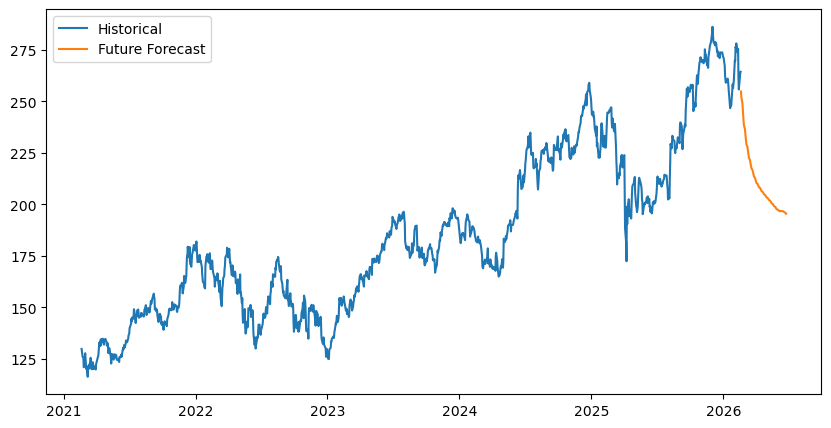

Feature : high


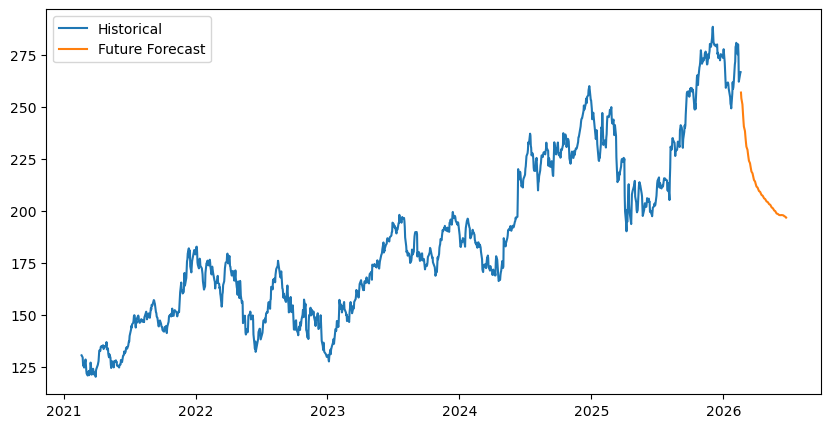

Feature : low


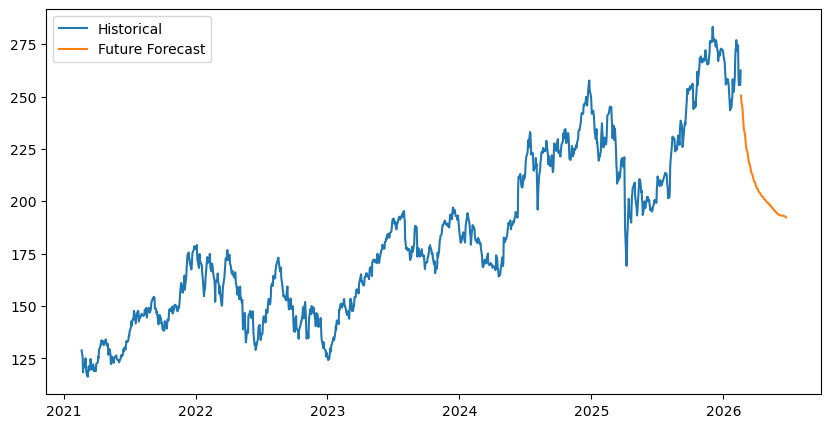

Feature : open


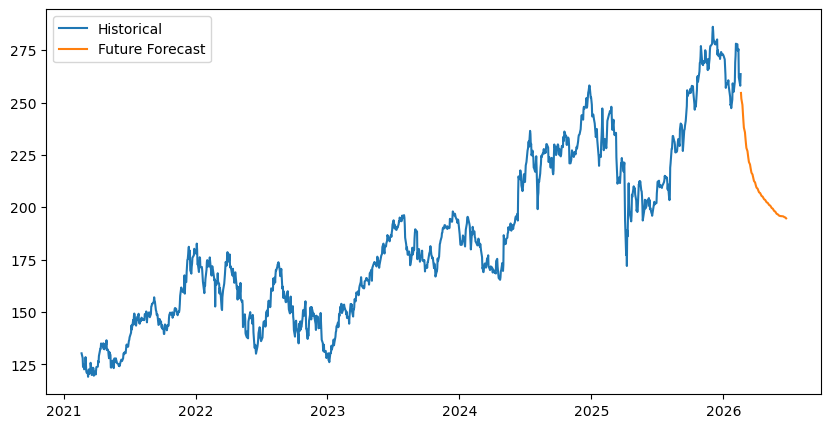

In [88]:
### plotting the graphs
gen_future_price_graphs(df, df_copy, features_to_target, future_dates_90, future_pred_90)